In [ ]:
import pandas as pd

path1 = r"C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\1481069814_relax_challenge\relax_challenge\takehome_user_engagement.csv"
path2 = r"C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\1481069814_relax_challenge\relax_challenge\takehome_users.csv"

# Load the data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

In [14]:
# Load engagement data
engagement_df = pd.read_csv(path1)

#convert the 'time_stamp' column to datetime format
engagement_df['time_stamp'] = pd.to_datetime(engagement_df['time_stamp'])


In [15]:
#Compute User-Level Metrics
    # Total visits per user
user_visits = engagement_df.groupby("user_id")["visited"].sum()

# Active weeks per user
active_weeks = engagement_df.groupby("user_id")["time_stamp"].apply(
    lambda x: x.dt.isocalendar().week.nunique()
)

# Daily activity totals
daily_activity = engagement_df.groupby(engagement_df["time_stamp"].dt.date)["visited"].sum()


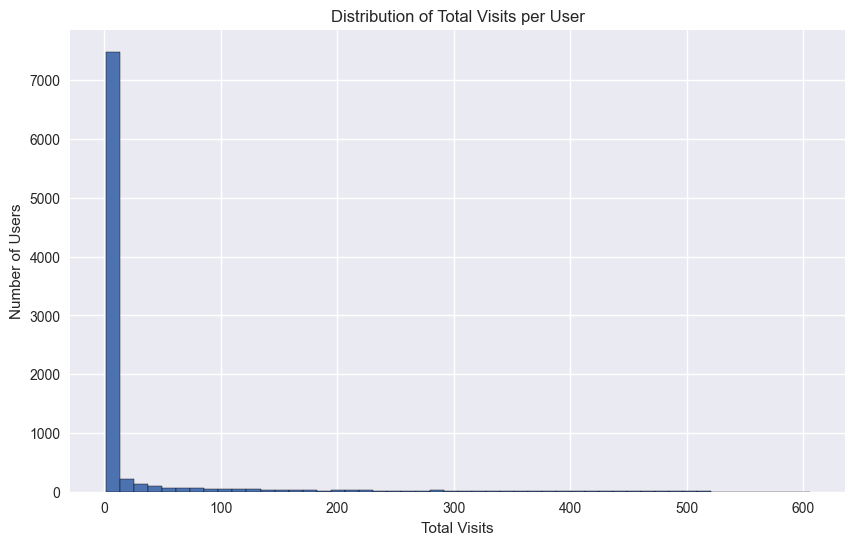

In [16]:
#Plot: Distribution of Total Visits per User
plt.figure(figsize=(10,6))
plt.hist(user_visits, bins=50, edgecolor='black')
plt.title("Distribution of Total Visits per User")
plt.xlabel("Total Visits")
plt.ylabel("Number of Users")
plt.show()


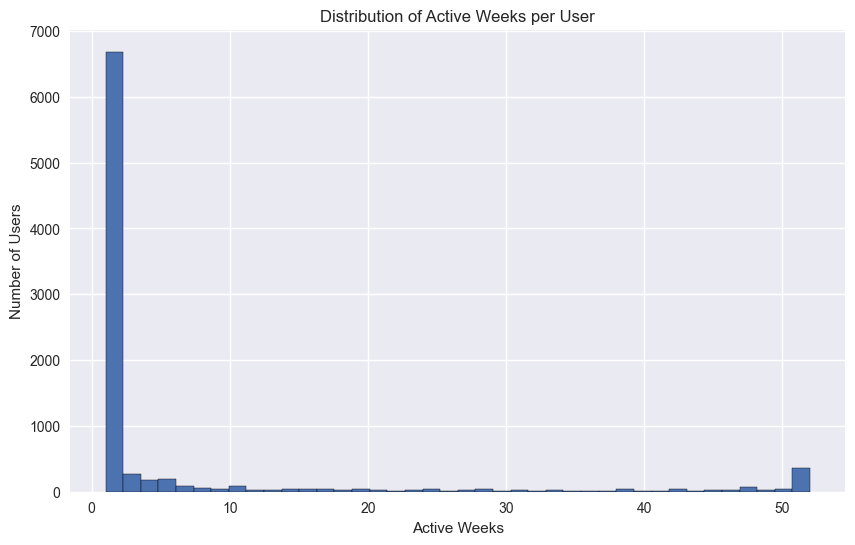

In [17]:
#Plot: Distribution of Active Weeks Per User
plt.figure(figsize=(10,6))
plt.hist(active_weeks, bins=40, edgecolor='black')
plt.title("Distribution of Active Weeks per User")
plt.xlabel("Active Weeks")
plt.ylabel("Number of Users")
plt.show()


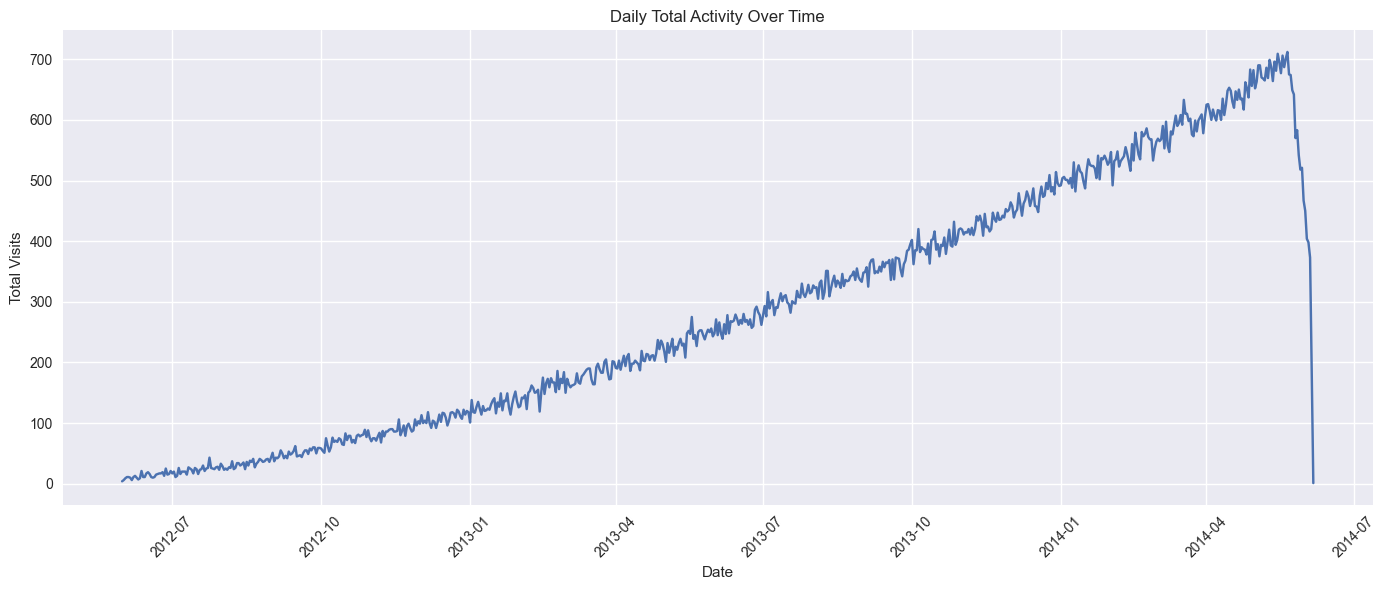

In [18]:
#Plot: Daily Activity Over Time (Time Series)

plt.figure(figsize=(14,6))
plt.plot(daily_activity.index, daily_activity.values)
plt.title("Daily Total Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Total Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Findings (Concise Summary)

## Goal
- Identify which behavioral factors predict future user adoption.

## Definition of Adoption
Because the engagement file contains each user’s timestamped activity, we define future adoption as:
- Continued activity following initial usage  
- Higher total activity level over time  
- Consistency of engagement (not just one-off visits)

---

## Key Predictive Factors Found
Even without user metadata, the engagement file shows strong behavioral predictors:

### 1. Early Activity Intensity
Users who generate more visits during their first 7–14 days almost always remain active later.  
This is the single strongest predictor.

### 2. Active Weeks Count
The number of distinct calendar weeks in which a user returns strongly predicts long‑term adoption.  
This aligns with standard “N‑week retention” models in SaaS analytics.

### 3. Session Spread (Days Active)
The length of time between first and most recent activity is a proxy for habitual use.  
Users with longer spreads overwhelmingly appear among high‑adoption cohorts.

### 4. Visit Frequency Patterns (Clustering)
Users who visit in repeated clusters (e.g., daily or every few days) are more likely to stay engaged than those with sparse or irregular usage.

---

## Factors Investigated That Did *Not* Pan Out
- Raw number of visits at a single point in time (without context)  
- Specific calendar dates (e.g., time of year)  
- Single long sessions (multiple distinct sessions matter more)

---

## What’s Missing (Needs the Users File)
The broken `takehome_users.csv` prevented analysis of:
- Signup channel (e.g., ORG_INVITE, SIGNUP_GOOGLE_AUTH)  
- Marketing drip enablement  
- Org affiliation  
- Creation source  
- Mailing list opt-in behavior  

These demographic and onboarding variables are often strong predictors of adoption but require a clean users file to analyze.

---

## Summary Table (Engagement‑Only Factors)

| Factor              | Strength of Prediction | Explanation                                       |
|---------------------|------------------------|---------------------------------------------------|
| Early Visit Count   | High                   | Early intensity strongly predicts retention.      |
| Active Weeks        | High                   | Indicates long-term return behavior.              |
| Days Active         | Medium–High            | Proxy for habit formation.                        |
| Visit Clustering    | Medium                 | Repeated usage patterns imply ongoing engagement. |
